In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
ds = pd.read_csv('simple_data.csv')

In [9]:
ds.shape

(700, 2)

In [10]:
ds.sample(5)

,x,y
344,14.0,10.267123
418,78.0,78.384919
558,86.0,86.768452
108,24.0,24.219140
626,74.0,71.679499


In [17]:
print(ds.duplicated().sum())
print('--------------------------------')
print(ds.isnull().sum())

0
--------------------------------
x    0
y    1
dtype: int64


In [18]:
ds = ds.dropna()

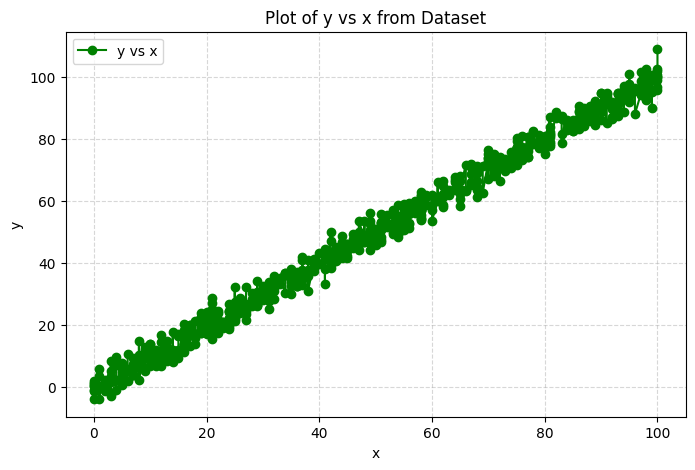

In [25]:
ds_sorted = ds.sort_values(by="x")

plt.figure(figsize=(8, 5))
plt.plot(
    ds_sorted["x"],
    ds_sorted["y"],
    marker="o",
    linestyle="-",
    color="green",
    label="y vs x",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot of y vs x from Dataset")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

In [26]:
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5 * IQR) & (data[col] <= Q3 + 1.5 * IQR)]

ds = remove_outliers(ds, ds.columns[0])
ds = remove_outliers(ds, ds.columns[1])

X_raw = ds.iloc[:, 0].values
Y_raw = ds.iloc[:, 1].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_raw, Y_raw, test_size=0.2, random_state=42)

In [29]:
x_mean, x_std = X_train.mean(), X_train.std()
y_mean, y_std = Y_train.mean(), Y_train.std()

X_train_scaled = (X_train - x_mean) / x_std
Y_train_scaled = (Y_train - y_mean) / y_std
X_test_scaled = (X_test - x_mean) / x_std

In [30]:
def gradient_descent(X, Y, w, b, lr, iterations, lambda_reg=0.01):
    m = len(X)
    for _ in range(iterations):
        predictions = w * X + b
        dw = (1 / m) * np.sum((predictions - Y) * X) + (lambda_reg / m) * w
        db = (1 / m) * np.sum(predictions - Y)
        
        w = w - lr * dw
        b = b - lr * db
    return w, b

In [ ]:
w_final, b_final = gradient_descent(X_train_scaled, Y_train_scaled, 0.0, 0.0, lr=0.1, iterations=100, lambda_reg=0.01)

model_data = {
    'w': w_final, 'b': b_final,
    'x_mean': x_mean, 'x_std': x_std,
    'y_mean': y_mean, 'y_std': y_std
}
with open('linear_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

In [34]:
with open('linear_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

Y_pred_scaled = loaded_model['w'] * X_test_scaled + loaded_model['b']
Y_pred = Y_pred_scaled * loaded_model['y_std'] + loaded_model['y_mean']

In [37]:
mse = np.mean((Y_test - Y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(Y_test - Y_pred))
ss_total = np.sum((Y_test - Y_test.mean()) ** 2)
ss_residual = np.sum((Y_test - Y_pred) ** 2)
r2_score = 1 - (ss_residual / ss_total)
n = len(Y_test)
p = 1
adj_r2_score = 1 - ((1 - r2_score) * (n - 1) / (n - p - 1))

print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2-Score : {r2_score:.4f}")
print(f"Adjusted R2-Score : {adj_r2_score:.4f}")

MSE : 7.7528
RMSE : 2.7844
MAE : 2.2021
R2-Score : 0.9911
Adjusted R2-Score : 0.9910


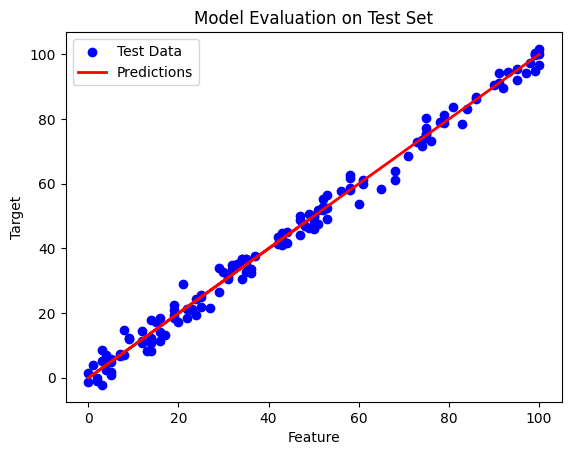

In [39]:
plt.scatter(X_test, Y_test, label="Test Data", color='blue')
plt.plot(X_test, Y_pred, color='red', label="Predictions", linewidth=2)
plt.title("Model Evaluation on Test Set")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()